/opt/anaconda3/lib/python3.12/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.6822, E_B=1.043057
N= 3, τ=0.5807, E_B=1.655069
N= 4, τ=0.5158, E_B=2.279733
N= 5, τ=0.4696, E_B=2.912334
N= 6, τ=0.4344, E_B=3.549775
N= 7, τ=0.4065, E_B=4.191798
N= 8, τ=0.3835, E_B=4.835493
N= 9, τ=0.3642, E_B=5.481757
N=10, τ=0.3478, E_B=6.132016
N=11, τ=0.3334, E_B=6.781138
N=12, τ=0.3208, E_B=7.433067
N=13, τ=0.3096, E_B=8.086251
N=14, τ=0.2996, E_B=8.741809
N=15, τ=0.2905, E_B=9.396403
N=16, τ=0.2823, E_B=10.054526
N=17, τ=0.2747, E_B=10.709777
N=18, τ=0.2678, E_B=11.369316
N=19, τ=0.2614, E_B=12.028438
N=20, τ=0.2555, E_B=12.689983
N=21, τ=0.2500, E_B=13.351846
N=22, τ=0.2448, E_B=14.010757
N=23, τ=0.2400, E_B=14.674409
N=24, τ=0.2355, E_B=15.339291
N=25, τ=0.2312, E_B=16.000530
N=26, τ=0.2272, E_B=16.666467
N=27, τ=0.2234, E_B=17.331763
N=28, τ=0.2198, E_B=17.997735
N=29, τ=0.2164, E_B=18.665828
N=30, τ=0.2131, E_B=19.328548
N=31, τ=0.2100, E_B=19.995752
N=32, τ=0.2071, E_B=20.669229
N=33, τ=0.2042, E_B=21.329987
N=34, τ=0.2015, E_B=21.999035
N=35, τ=0.1989, E_B=22.6

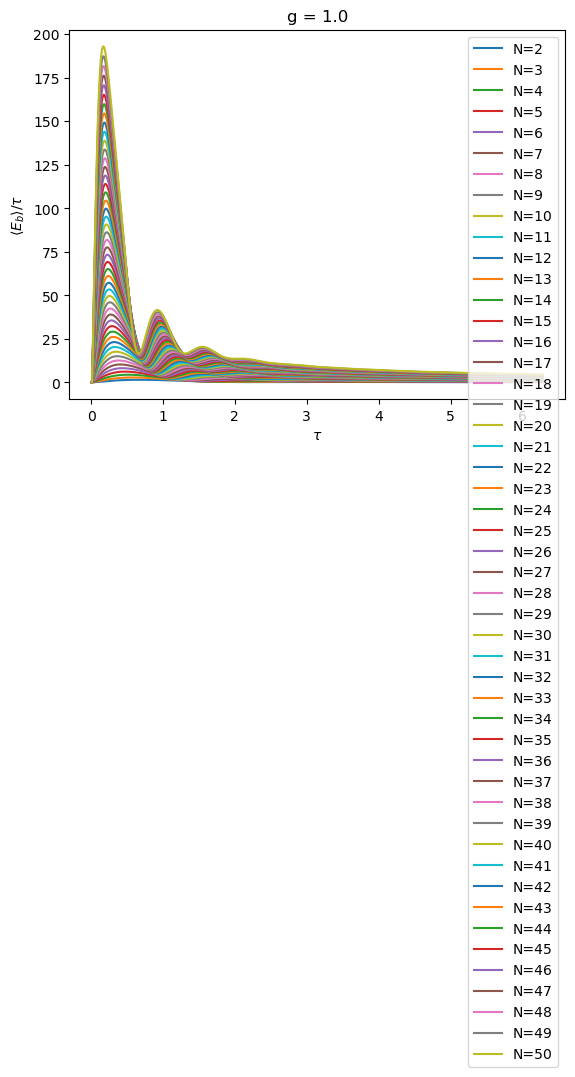

N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.0201683688, erg/Eb=0.964113651149 Variance=5.7360130333e-01
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.6366653333, erg/Eb=0.972388170139 Variance=8.8272458818e-01
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.2706982979, erg/Eb=0.977394390424 Variance=1.1937538485e+00
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.9160908912, erg/Eb=0.980767557910 Variance=1.5059273173e+00
N= 6, τ=0.4344, Eb=3.629995, Ergotropy=3.5690765661, erg/Eb=0.983217925261 Variance=1.8187600085e+00
N= 7, τ=0.4065, Eb=4.292903, Ergotropy=4.2288107504, erg/Eb=0.985070184249 Variance=2.1321818007e+00
N= 8, τ=0.3835, Eb=4.959030, Ergotropy=4.8922977259, erg/Eb=0.986543280721 Variance=2.4458189472e+00
N= 9, τ=0.3642, Eb=5.629109, Ergotropy=5.5600546810, erg/Eb=0.987732639320 Variance=2.7597658646e+00
N=10, τ=0.3478, Eb=6.304395, Ergotropy=6.2331728362, erg/Eb=0.988702701519 Variance=3.0741364854e+00
N=11, τ=0.3334, Eb=6.979894, Ergotropy=6.9068565474, erg/Eb=0.989536071519 Variance=3.38841

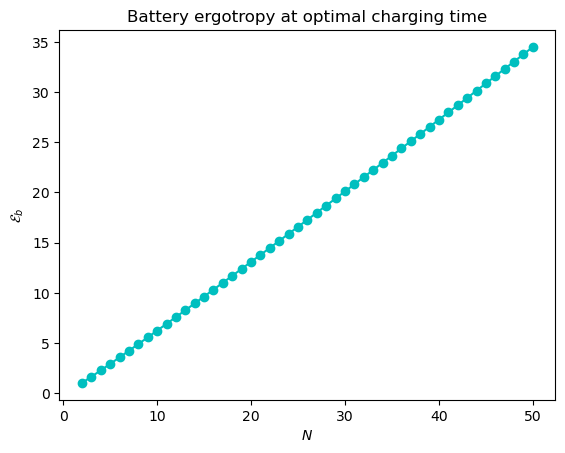

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from scipy.special import comb
from itertools import product

############
# parameters
############

N_arr = np.arange(2, 51, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2,'+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2,'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    IB = qt.qeye(N+1)
    H = ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))
    return H, HB

################
# Passive state
################

def passive_state(rho, H):
    r_val, r_vec = rho.eigenstates()
    
    # Keep formalism intact from the notebook
    r_val = np.maximum(r_val, 0)
    r_val = r_val / np.sum(r_val)
    
    idx = np.argsort(r_val)[::-1]          # descending order
    r_val = r_val[idx]

    e_val, e_vec = H.eigenstates()         # ascending order

    return np.sum(r_val[i] * e_vec[i] * e_vec[i].dag()
               for i in range(len(r_val)))

########################
# ergotropy calculation
########################

def ergotropy(ρ, H):
    ρ_p = passive_state(ρ, H)
    return qt.expect(H, ρ) - qt.expect(H, ρ_p)

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, N)  
    return qt.tensor(psiA, psiB)

##############
# Pnm matrix
##############

def pnm_matrix(rho, H):
    r_val, r_vec = rho.eigenstates()
    
    # --- CORRECTION STARTS HERE ---
    # Clip numerical noise to prevent negative probabilities
    r_val = np.maximum(r_val, 0) 
    # Renormalize 
    r_val = r_val / np.sum(r_val)
    # --- CORRECTION ENDS HERE ---
    
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)

############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

###########################
# Extracting Coefficients
###########################

def extract_Cn_dicke(rho_b, N):
    dim = rho_b.shape[0]
    diag = np.real(rho_b.diag())

    Cn = np.zeros(N+1)

    for idx, state in enumerate(product([0,1], repeat=N)):
        n_exc = sum(state)  
        Cn[n_exc] += diag[idx]

    return Cn

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################

τ_list = []
# Ensure opts is instantiated globally to apply to all ODE evaluations uniformly
opts = qt.Options(atol=1e-16, rtol=1e-14)

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(1)

    Eb = qt.expect(HB, ρb)

    # Generate the correct TPM probability matrix using the function from Cell 0.
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    erg = 0
    mean_E_sq = 0

    # Calculate TPM ergotropy and variance mapping to the full space
    for n in range(len(e_val)):
        En = e_val[n]
        for m in range(len(e_val)):
            
            # MAPPING TO FULL SPACE:
            # The full 2^N space has degeneracy 1 at E=0, and degeneracy N at E=ω0.
            # Since ρb has exactly N+1 non-zero eigenvalues, the passive state 
            # places the largest eigenvalue (m=0) in E=0, and the remaining N (m>0) in E=ω0.
            Em_pass = 0 if m == 0 else ω0
            
            ΔE = En - Em_pass
            
            erg += pnm[n, m] * ΔE
            mean_E_sq += pnm[n, m] * (ΔE**2)

    var = mean_E_sq - erg**2

    ratio = erg / Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.10f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)
    
Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list) 
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr
rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

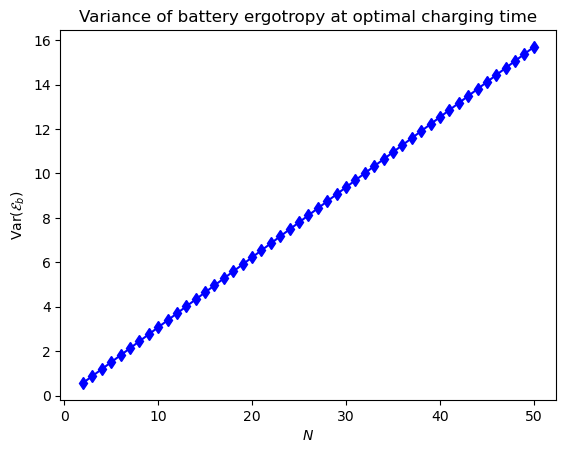

In [3]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

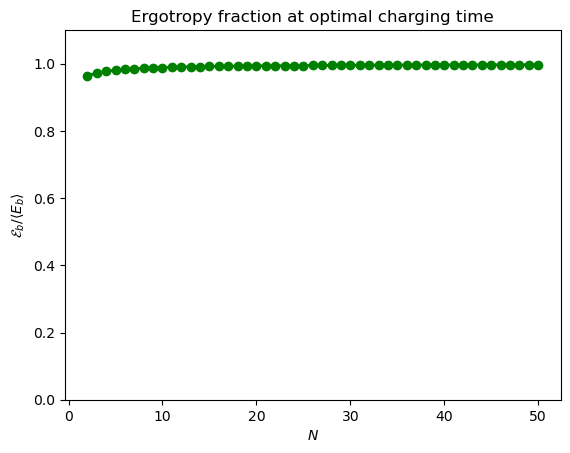

In [7]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.6822, Relative Fluctuation = 0.742391876427, Relative Fluctuation with Eb = 0.715750142565
N= 3, τ=0.5807, Relative Fluctuation = 0.574053974810, Relative Fluctuation with Eb = 0.558203294127
N= 4, τ=0.5158, Relative Fluctuation = 0.481169352761, Relative Fluctuation with Eb = 0.470292226233
N= 5, τ=0.4696, Relative Fluctuation = 0.420824435350, Relative Fluctuation with Eb = 0.412730953767
N= 6, τ=0.4344, Relative Fluctuation = 0.377860794417, Relative Fluctuation with Eb = 0.371519506324
N= 7, τ=0.4065, Relative Fluctuation = 0.345297843623, Relative Fluctuation with Eb = 0.340142610438
N= 8, τ=0.3835, Relative Fluctuation = 0.319668080981, Relative Fluctuation with Eb = 0.315366397352
N= 9, τ=0.3642, Relative Fluctuation = 0.298783806981, Relative Fluctuation with Eb = 0.295118518255
N=10, τ=0.3478, Relative Fluctuation = 0.281288776036, Relative Fluctuation with Eb = 0.278110972774
N=11, τ=0.3334, Relative Fluctuation = 0.266512641177, Relative Fluctuation with Eb = 0.263

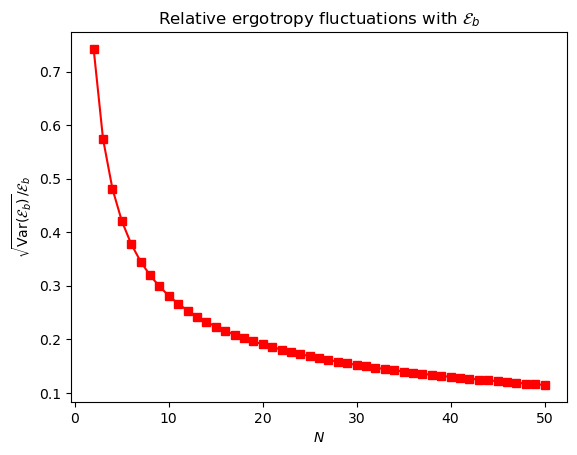

In [11]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation = {rel_fluct[idx]:.12f}, Relative Fluctuation with Eb = {rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
plt.show()

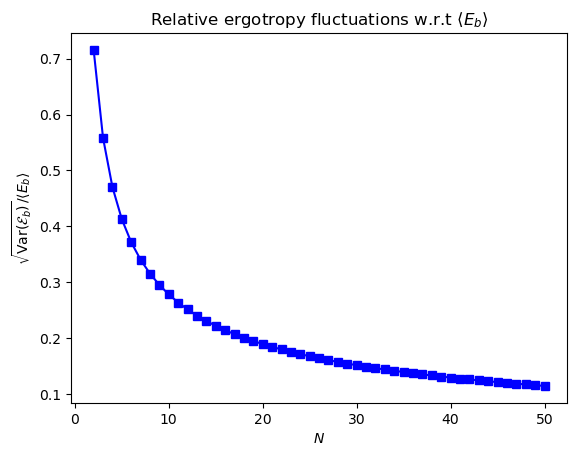

In [13]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()